In [24]:
import numpy as np
import pandas as pd 
import json
from hbv_bmi_project import HBV_Bmi
import xarray as xr

In [ ]:
df = pd.read_csv("ERA5_Temp_1980_2026.csv")

# Parse year and month from the index (format: YYYYMM)
df['year'] = df['system:index'].astype(str).str[:4].astype(int)
df['month'] = df['system:index'].astype(str).str[4:6].astype(int)
 
# Convert temperature from Kelvin to Celsius
df['temperature_C'] = df['temperature_2m'] - 273.15
 
# Calculate mean annual temperature (average all months per year)
annual_mean = df.groupby('year')['temperature_C'].mean()
 
# Assign each year to a decade (e.g., 1980-1989 → 1980s)
annual_mean_df = annual_mean.reset_index()
annual_mean_df.columns = ['year', 'mean_annual_temp_C']
annual_mean_df['decade'] = (annual_mean_df['year'] // 10) * 10
 
# Calculate mean temperature per decade
decadal_mean = annual_mean_df.groupby('decade')['mean_annual_temp_C'].mean().reset_index()
decadal_mean.columns = ['decade', 'mean_decadal_temp_C']
 
print("Mean Annual Temperature per Year:")
print(annual_mean_df.to_string(index=False))
print("\nMean Temperature per Decade:")
print(decadal_mean.to_string(index=False))
 
# Pivot table: rows = years, columns = months (Jan=1 ... Dec=12)
pivot = df.pivot_table(index='year', columns='month', values='temperature_C')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.index.name = 'year'
 
#print("\nMonthly Mean Temperature per Year (°C):")
#print(pivot.round(2).to_string())

Mean Annual Temperature per Year:
 year  mean_annual_temp_C  decade
 1980            7.973034    1980
 1981            8.474816    1980
 1982            9.249956    1980
 1983            9.250297    1980
 1984            8.350761    1980
 1985            7.820802    1980
 1986            8.149693    1980
 1987            8.072648    1980
 1988            9.459149    1980
 1989            9.858341    1980
 1990            9.866679    1990
 1991            8.950346    1990
 1992            9.638510    1990
 1993            9.042281    1990
 1994           10.184077    1990
 1995            9.518560    1990
 1996            7.946916    1990
 1997            9.287314    1990
 1998            9.076644    1990
 1999            9.614176    1990
 2000            9.938774    2000
 2001            9.376367    2000
 2002            9.934531    2000
 2003           10.092163    2000
 2004            9.192590    2000
 2005            9.413167    2000
 2006            9.978638    2000
 2007         

In [26]:
# Extract monthly mean temperatures for 1980-2020 as a 1D array
temp_1980_2020 = pivot.loc[1980:2020].values.flatten()
print(f"Monthly temperature array shape: {temp_1980_2020.shape}")
print(f"First 12 values (Jan-Dec 1980): {temp_1980_2020[:12]}")
print(f"Last 12 values (Jan-Dec 2020): {temp_1980_2020[-12:]}")
print(f"\nArray: {temp_1980_2020}")


Monthly temperature array shape: (492,)
First 12 values (Jan-Dec 1980): [-1.00103054  3.84723186  4.62921448  6.30690846 10.86167125 13.82727167
 14.54344663 16.57418022 14.6393308   8.34936158  2.92144297  0.1773746 ]
Last 12 values (Jan-Dec 2020): [ 3.78641294  5.46021825  5.75547273 11.80409456 13.20353548 16.61906182
 18.95159186 21.13463737 16.77357425 10.36604547  7.02498276  3.91438601]

Array: [-1.00103054e+00  3.84723186e+00  4.62921448e+00  6.30690846e+00
  1.08616712e+01  1.38272717e+01  1.45434466e+01  1.65741802e+01
  1.46393308e+01  8.34936158e+00  2.92144297e+00  1.77374602e-01
 -6.54509796e-01 -1.31626752e-02  7.38500702e+00  8.44216969e+00
  1.21274618e+01  1.44612798e+01  1.60168384e+01  1.67198913e+01
  1.43578249e+01  8.51588738e+00  4.72657892e+00 -3.87469909e-01
 -7.20549083e-01  1.76030182e+00  4.25276828e+00  6.68601671e+00
  1.22143833e+01  1.63491445e+01  1.90099002e+01  1.65793372e+01
  1.63404212e+01  9.62939805e+00  6.51466287e+00  2.38368600e+00
  3.447391

In [ ]:
grdc_obs = pd.read_csv(
    "/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt",
    encoding="latin-1",
    sep=";",
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc_obs.index.name = "date"
grdc_obs.columns = ["Observations from GRDC"]

print(grdc_obs)

shape_area = 28191724718

            Observations from GRDC
date                              
1930-12-07                   415.0
1930-12-08                   388.0
1930-12-09                   378.0
1930-12-10                   391.0
1930-12-11                   388.0
...                            ...
2020-12-27                   568.0
2020-12-28                   663.0
2020-12-29                   698.0
2020-12-30                   729.0
2020-12-31                   636.0

[32898 rows x 1 columns]


In [28]:
# Load precipitation and evaporation monthly data
precip_df = pd.read_csv("/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project/Moselle_ERA5_monthly_precip_1980-01-01_2026-02-28.csv")
evap_df = pd.read_csv("/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project/Moselle_ERA5_monthly_evap_1980-01-01_2026-02-28.csv")

# Parse the system:index column (YYYYMM format) and filter to 1980-2020
precip_df['yyyymm'] = precip_df['system:index']
precip_df = precip_df[(precip_df['yyyymm'] >= 198001) & (precip_df['yyyymm'] <= 202012)].reset_index(drop=True)

evap_df['yyyymm'] = evap_df['system:index']
evap_df = evap_df[(evap_df['yyyymm'] >= 198001) & (evap_df['yyyymm'] <= 202012)].reset_index(drop=True)

# Create monthly date index for 1980-2020 (Jan 1980 to Dec 2020)
date_range_monthly = pd.date_range(start='1980-01-01', end='2020-12-31', freq='MS')

# Aggregate daily discharge observations to monthly mean
grdc_monthly = grdc_obs.copy()
grdc_monthly['year'] = grdc_monthly.index.year
grdc_monthly['month'] = grdc_monthly.index.month
discharge_monthly = grdc_monthly.groupby(['year', 'month'])['Observations from GRDC'].mean().reset_index()
discharge_monthly['date'] = pd.to_datetime(discharge_monthly[['year', 'month']].assign(day=1))
discharge_monthly = discharge_monthly[(discharge_monthly['year'] >= 1980) & (discharge_monthly['year'] <= 2020)].sort_values('date').reset_index(drop=True)

# Create the combined monthly dataframe
monthly_df = pd.DataFrame({
    'Date': date_range_monthly.values,
    'precipitation': precip_df['total_precipitation_sum'].values,
    'evaporation': evap_df[evap_df.columns[1]].values,  # Get the second column (evaporation values)
    'temperature': temp_1980_2020,
    'discharge': discharge_monthly['Observations from GRDC'].values
})

print("Monthly DataFrame (1980-2020):")
print(monthly_df.head(12))
print(f"\nShape: {monthly_df.shape}")
print(f"\nColumn dtypes:\n{monthly_df.dtypes}")
print(f"\nSummary statistics:\n{monthly_df.describe()}")

Monthly DataFrame (1980-2020):
         Date  precipitation  evaporation  temperature   discharge
0  1980-01-01       0.077218    -0.006487    -1.001031  592.322581
1  1980-02-01       0.081914    -0.021555     3.847232  896.241379
2  1980-03-01       0.089754    -0.037676     4.629214  269.935484
3  1980-04-01       0.060644    -0.064560     6.306908  293.433333
4  1980-05-01       0.073371    -0.092885    10.861671  180.354839
5  1980-06-01       0.123058    -0.089279    13.827272  166.233333
6  1980-07-01       0.144232    -0.083601    14.543447  582.290323
7  1980-08-01       0.100759    -0.084409    16.574180  194.806452
8  1980-09-01       0.040687    -0.060524    14.639331  135.933333
9  1980-10-01       0.080884    -0.034231     8.349362  213.000000
10 1980-11-01       0.068660    -0.015680     2.921443  261.466667
11 1980-12-01       0.091563    -0.007841     0.177375  549.354839

Shape: (492, 5)

Column dtypes:
Date             datetime64[ns]
precipitation           float64
e

In [29]:
growing_season_mask = (monthly_df['Date'].dt.month >= 4) & (monthly_df['Date'].dt.month <= 10)
monthly_df_growing = monthly_df[growing_season_mask].copy()
mean_temp = np.mean(monthly_df_growing['temperature'])
monthly_df_growing['delT'] = monthly_df_growing['temperature'] - mean_temp
print(monthly_df_growing.head())

        Date  precipitation  evaporation  temperature   discharge      delT
3 1980-04-01       0.060644    -0.064560     6.306908  293.433333 -7.668838
4 1980-05-01       0.073371    -0.092885    10.861671  180.354839 -3.114075
5 1980-06-01       0.123058    -0.089279    13.827272  166.233333 -0.148475
6 1980-07-01       0.144232    -0.083601    14.543447  582.290323  0.567700
7 1980-08-01       0.100759    -0.084409    16.574180  194.806452  2.598434


In [30]:
# Unit check and conversion for HBV inputs (model-ready)
check_df = monthly_df_growing.copy()
check_df['days_in_month'] = check_df['Date'].dt.days_in_month

# ERA5 monthly totals are in meters of water; convert to mm/month
check_df['precip_mm_month'] = check_df['precipitation'] * 1000.0

# ERA5 evaporation is typically negative downward flux; use positive PET demand
check_df['pet_mm_month'] = (-check_df['evaporation']).clip(lower=0) * 1000.0

# HBV wrapper works with rate input and multiplies by dt internally, so use mm/day
check_df['precip_mm_day'] = check_df['precip_mm_month'] / check_df['days_in_month']
check_df['pet_mm_day'] = check_df['pet_mm_month'] / check_df['days_in_month']

# GRDC discharge is m3/s; convert to catchment-depth equivalent mm/day for NSE vs model Q
check_df['q_obs_mm_day'] = check_df['discharge'] * 86400.0 / shape_area * 1000.0

print('Unit check summary:')
print(check_df[['precipitation', 'evaporation', 'discharge']].describe())
print('\nConverted (use these for MC):')
print(check_df[['Date', 'precip_mm_day', 'pet_mm_day', 'q_obs_mm_day']].head(12))

# Optional arrays for the MC cell
precip_array = check_df['precip_mm_day'].to_numpy()
evap_array = check_df['pet_mm_day'].to_numpy()
temp_array = check_df['temperature'].to_numpy()
q_obs_array = check_df['q_obs_mm_day'].to_numpy()
print(f'\nArray lengths -> P:{len(precip_array)}, EP:{len(evap_array)}, T:{len(temp_array)}, Qobs:{len(q_obs_array)}')

Unit check summary:
       precipitation  evaporation    discharge
count     287.000000   287.000000   287.000000
mean        0.078430    -0.078311   171.379603
std         0.034449     0.025480   142.127617
min         0.003944    -0.129790    43.419355
25%         0.053958    -0.099102    81.903226
50%         0.072242    -0.083923   129.580645
75%         0.099655    -0.058811   200.221505
max         0.215272    -0.025601  1081.161290

Converted (use these for MC):
         Date  precip_mm_day  pet_mm_day  q_obs_mm_day
3  1980-04-01       2.021470    2.152004      0.899294
4  1980-05-01       2.366812    2.996306      0.552739
5  1980-06-01       4.101950    2.975972      0.509460
6  1980-07-01       4.652650    2.696813      1.784562
7  1980-08-01       3.250283    2.722882      0.597029
8  1980-09-01       1.356227    2.017470      0.416599
9  1980-10-01       2.609167    1.104230      0.652787
15 1981-04-01       1.986574    1.999701      0.850564
16 1981-05-01       2.905248   

In [31]:
# Can revise the max and min ranges later 
#                   Imax Ce Sumax0 beta Pmax   Tlag   Kf  Ks Gamma
ParMinn = np.array([0,   0.2,  40,    .5,   .001,   0,     .01,  .0001, -0.05])
ParMaxn = np.array([8,    1,  800,   4,    .3,     10,    .1,   .01, 0.2])
Sin = np.array([0,  100,  0,  5  ])

In [32]:
# Use growing-season monthly arrays prepared in the unit-conversion cell
if any(arr.size == 0 for arr in (precip_array, evap_array, temp_array, q_obs_array)):
    raise ValueError('Run the unit-conversion cell first to create growing-season arrays.')

# Keep a regular monthly model timeline (no seasonal gaps in model time step)
# while forcing values come from Apr-Oct samples only.
time_index = pd.date_range(start='1980-04-01', periods=len(precip_array), freq='MS')

precip_da = xr.DataArray(precip_array, coords={'time': time_index}, dims=('time',), name='pr')
evap_da = xr.DataArray(evap_array, coords={'time': time_index}, dims=('time',), name='evspsblpot')
temp_da = xr.DataArray(temp_array, coords={'time': time_index}, dims=('time',), name='tas')
Q_obs = np.asarray(q_obs_array)

config = {
    'precipitation_file': precip_da,
    'potential_evaporation_file': evap_da,
    'temperature_file': temp_da,
    'T_baseline': 8.99,
    'initial_storage': '0.0,50.0,0.0,0.0',
}

print(f'Monthly growing-season setup ready. Steps: {len(time_index)}')
print(f'Time step example: {(time_index[1] - time_index[0]).days} days')

Monthly growing-season setup ready. Steps: 287
Time step example: 30 days


In [35]:
def nse(obs, sim):
    """Nash-Sutcliffe Efficiency"""
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    return 1 - (np.sum((obs - sim) ** 2) / np.sum((obs - np.mean(obs)) ** 2))

N = 1000 # Number of runs
results = []

# Assuming you have observed discharge Q_obs as a numpy array or series
for i in range(N):
    # 1. Select random parameters from your ParMinn/ParMaxn
    p = np.random.uniform(ParMinn, ParMaxn)

    # 2. Initialize the model from in-memory forcing arrays
    model = HBV_Bmi()
    model.initialize(config)
    model.set_pars(p)

    # 3. Run the full time series
    sim_q = []
    while model.current_timestep < model.end_timestep:
        model.update()
        dest = np.array([0.0])
        model.get_value('Q', dest)
        sim_q.append(dest[0])

    # 4. Score the run against observations
    score = nse(Q_obs, np.array(sim_q))
    results.append((score, p))

# Find the best parameter set
best_run = max(results, key=lambda x: x[0])
print(f'Best NSE: {best_run[0]}')
print(f'Best Parameters: {best_run[1]}')

Best NSE: -0.022008716382284632
Best Parameters: [1.20454022e+00 5.12680457e-01 9.82943990e+01 2.72672357e+00
 2.99993087e-01 6.94159380e-01 3.86850193e-02 2.51694262e-03
 1.39882859e-01]


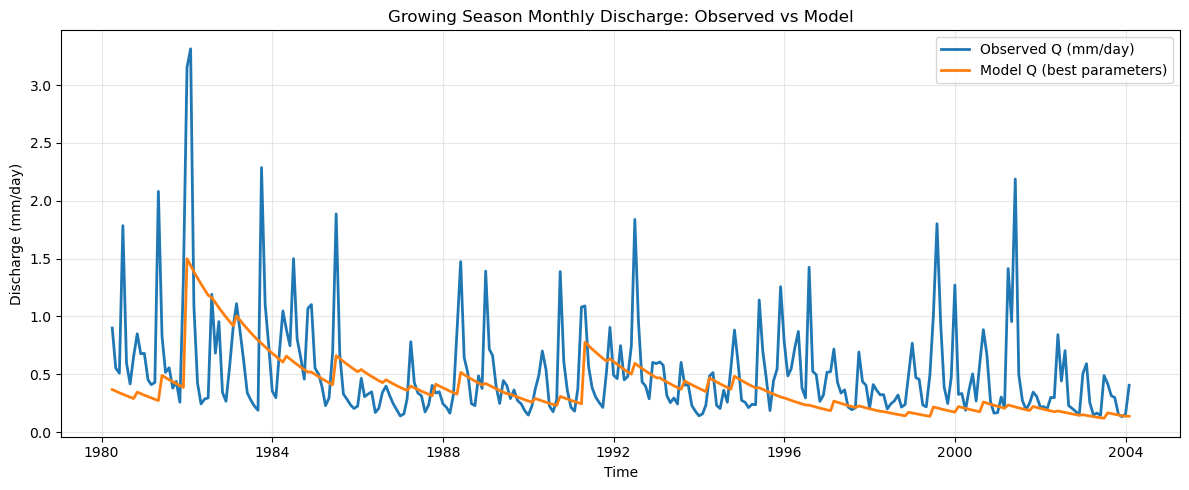

Best NSE: -0.0220


In [36]:
import matplotlib.pyplot as plt

# Re-run model with the best parameter set to get the full simulated Q series
best_params = best_run[1]
plot_model = HBV_Bmi()
plot_model.initialize(config)
plot_model.set_pars(best_params)

best_sim_q = []
while plot_model.current_timestep < plot_model.end_timestep:
    plot_model.update()
    q_dest = np.array([0.0])
    plot_model.get_value('Q', q_dest)
    best_sim_q.append(q_dest[0])

best_sim_q = np.asarray(best_sim_q)

plt.figure(figsize=(12, 5))
plt.plot(time_index, Q_obs, label='Observed Q (mm/day)', linewidth=2)
plt.plot(time_index, best_sim_q, label='Model Q (best parameters)', linewidth=2)
plt.title('Growing Season Monthly Discharge: Observed vs Model')
plt.xlabel('Time')
plt.ylabel('Discharge (mm/day)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best NSE: {best_run[0]:.4f}')